# Task 2. Data Analysis In Python. Mini-project Autumn 2024 
- Student: Jens Christian Aanestad

### Imports 

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

### Functions for cleaning the data and more...

In [42]:
def remove_unwanted_columns(df, columns: []):
    """Removes specified columns from the provided DataFrame."""
    df = df.drop(columns=columns, errors='ignore')
    return df


def replace_nan_with_zero(df, columns: []):
    """Replaces nan values with zero for specified columns."""
    df[columns] = df[columns].fillna(0)
    return df


def replace_missing_department_with_unknown(df):
    """Replaces missing values with 'unknown' in the department column"""
    df['department'] = df['department'].fillna('unknown')
    return df


def replace_nan_with_grouped_median(df, column='satisfaction', group_by_column='department'):
    """Replaces NaN values with the median for a specified column, grouped by a specified column."""
    groups = df.groupby(group_by_column)
    for group_name, group_df in groups:
        median_value = group_df[column].median(skipna=True)
        if pd.isnull(median_value):
            median_value = df[column].median(skipna=True)
        df.loc[df[group_by_column] == group_name, column] = df.loc[df[group_by_column] == group_name, column].fillna(median_value)
    return df


def remove_rows_with_missing_values(df, columns=None):
    """Remove rows with missing values in the specified columns."""
    if columns:
        return df.dropna(subset=columns)
    return df.dropna()


def count_missing_data(df):
    """Counts missing values in dataframe."""
    return df.isnull().sum()


def calculate_f1_score(y_true, y_pred):
    """Calculates the F1-scores for both classes (0 and 1) manually based on a confusion matrix."""
    c_m = confusion_matrix(y_true, y_pred)
    
    # Precision and Recall for class 0
    precision_0 = c_m[0][0] / (c_m[0][0] + c_m[1][0])
    recall_0 = c_m[0][0] / (c_m[0][0] + c_m[0][1])
    
    # Precision and Recall for class 1
    precision_1 = c_m[1][1] / (c_m[1][1] + c_m[0][1])
    recall_1 = c_m[1][1] / (c_m[1][1] + c_m[1][0])
    
    # F1-scores for class 0 and class 1
    f1_0 = round((2 * precision_0 * recall_0) / (precision_0 + recall_0), 4)
    f1_1 = round((2 * precision_1 * recall_1) / (precision_1 + recall_1), 4)

    return f1_0, f1_1, round(recall_0, 4), round(recall_1, 4)


### Cleaning the employee-status.csv file

In [43]:
# Assumptions for cleaning of dataset:
# I assume that employees that have missing values in 'filed_complaint' should be zero
# I also consider removing rows with empty 'department' values, but I decided to rename 
# them to 'unknown' to see if this could improve models. The same also is 
# considered for 'tenure'. There are no occasions where the tenure is equal to 1 or 0, 
# making it a doubtful decision. However, for 'tenure' I have chosen to replace nan with zeros, because 
# it is unlikely that any company never have had an employee for less than a year.
def get_cleaned_dataset():
    """Returns the cleaned dataset by removing irrelevant columns and incomplete rows"""
    df_employee_status = pd.read_csv('./employee-status.csv')
    columns_to_remove = ['last_evaluation', 'recently_promoted']
    df_employee_status = remove_unwanted_columns(df_employee_status, columns_to_remove)
    df_employee_status = replace_nan_with_zero(df_employee_status, 'filed_complaint')
    df_employee_status = replace_missing_department_with_unknown(df_employee_status)
    # df_employee_status = remove_rows_with_missing_values(df_employee_status, ['department']) # Alternatively, replace line above with this to remove missing department values
    df_employee_status = replace_nan_with_grouped_median(df_employee_status, column='satisfaction',group_by_column='department')
    df_employee_status = replace_nan_with_zero(df_employee_status, 'tenure')
    # df_employee_status = remove_rows_with_missing_values(df_employee_status, ['tenure']) # Alternatively, replace line above with this to remove missing tenure values
    
    return df_employee_status


df = get_cleaned_dataset()
df
# print(count_missing_data(get_cleaned_dataset()))

C:\Users\jensc\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,avg_monthly_hrs,department,filed_complaint,n_projects,salary,satisfaction,status,tenure
0,221,engineering,0.0,4,low,0.829896,Left,5.0
1,232,support,0.0,3,low,0.834544,Employed,2.0
2,184,sales,0.0,3,medium,0.834988,Employed,3.0
3,206,sales,0.0,4,low,0.424764,Employed,2.0
4,249,sales,0.0,3,low,0.779043,Employed,3.0
...,...,...,...,...,...,...,...,...
14244,178,IT,0.0,5,low,0.263282,Employed,5.0
14245,257,sales,0.0,3,low,0.868209,Employed,2.0
14246,232,finance,1.0,5,medium,0.898917,Left,5.0
14247,130,IT,0.0,4,medium,0.641304,Employed,3.0


## a)

In [44]:
df_monthly_hrs_above_200 = df[df['avg_monthly_hrs'] > 200]
mean_satisfaction = df_monthly_hrs_above_200['satisfaction'].mean()
print(f"The mean satisfaction score of employees with an average of more than 200 hours worked per month is {mean_satisfaction:.2f}")

The mean satisfaction score of employees with an average of more than 200 hours worked per month is 0.63


## b)

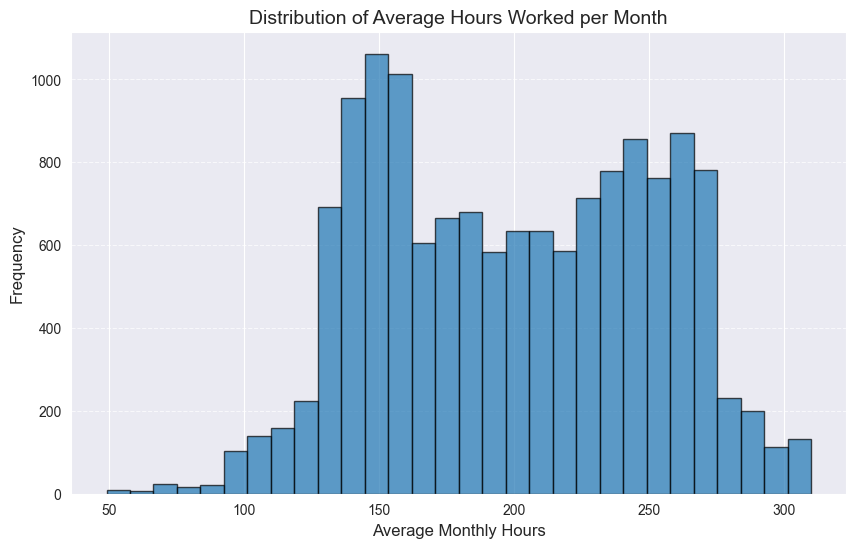

In [45]:
# Plot for the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['avg_monthly_hrs'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Average Hours Worked per Month', fontsize=14)
plt.xlabel('Average Monthly Hours', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## c)

Regression Coefficient: -0.0001
Intercept: 0.6429


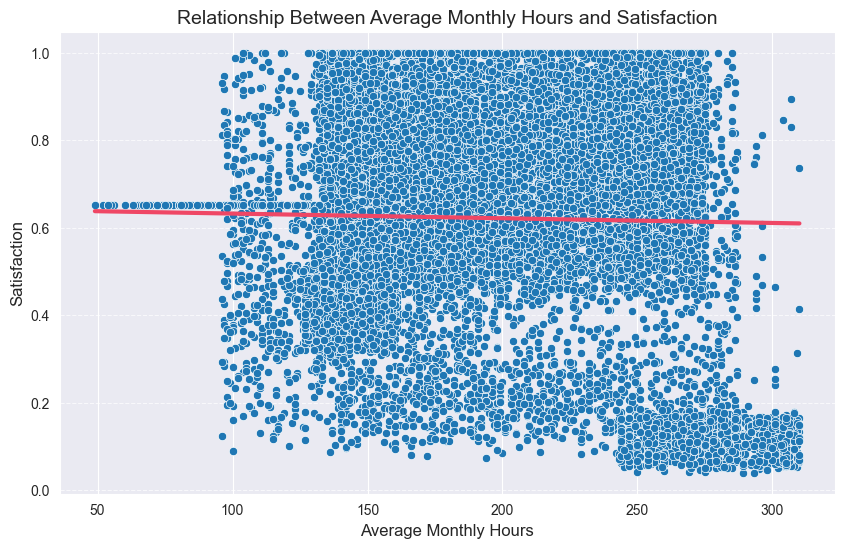

R-squared: 0.0005
Mean Absolute Error (MAE): 0.2054
Mean Squared Error (MSE): 0.0610
Root Mean Squared Error (RMSE): 0.2470

The R2 score is extremely low (0.0005), indicating this model explain almost nothing of the variance.
The Mean Absolute Error (MAE) of 0.2054 suggests that the average absolute difference between 
predicted and actual satisfaction scores is very small, but this is likely due to the limited range 
of satisfaction values (0 to 1). The Mean Squared Error (MSE) of  0.0610 and Root Mean Squared Error 
(RMSE) of 0.2470 further confirm that the prediction errors are small, though they lack practical 
significance given the poor model fit. Overall, there does not appear to be any linear relationship 
between average monthly hours worked and satisfaction. The regression line is nearly horizontal, further 
confirming the lack of a linear trend (even though it seems to be a trend in the interval from 50 to 100).
As a conclusion, satisfaction is likely influenced by other fa

In [46]:
# Scatter plot for the data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avg_monthly_hrs', y='satisfaction', data=df)
plt.title('Relationship Between Average Monthly Hours and Satisfaction', fontsize=14)
plt.xlabel('Average Monthly Hours', fontsize=12)
plt.ylabel('Satisfaction', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)


X = df['avg_monthly_hrs'].values.reshape(-1, 1)
y = df['satisfaction'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a simple linear regression model
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred_dt = reg.predict(X_test)

print(f"Regression Coefficient: {reg.coef_[0]:.4f}")
print(f"Intercept: {reg.intercept_:.4f}")
# Regression line
x_range = np.linspace(df['avg_monthly_hrs'].min(), df['avg_monthly_hrs'].max(), 100)
y_range = reg.coef_[0] * x_range + reg.intercept_
plt.plot(x_range, y_range, color='#EF4765', linewidth=3, label='Regression Line')
plt.show()

r2 = r2_score(y_test, y_pred_dt)
mae = mean_absolute_error(y_test, y_pred_dt)
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print(
f"""\nThe R2 score is extremely low ({r2:.4f}), indicating this model explain almost nothing of the variance.
The Mean Absolute Error (MAE) of {mae:.4f} suggests that the average absolute difference between 
predicted and actual satisfaction scores is very small, but this is likely due to the limited range 
of satisfaction values (0 to 1). The Mean Squared Error (MSE) of  {mse:.4f} and Root Mean Squared Error 
(RMSE) of {rmse:.4f} further confirm that the prediction errors are small, though they lack practical 
significance given the poor model fit. Overall, there does not appear to be any linear relationship 
between average monthly hours worked and satisfaction. The regression line is nearly horizontal, further 
confirming the lack of a linear trend (even though it seems to be a trend in the interval from 50 to 100).
As a conclusion, satisfaction is likely influenced by other factors beyond average monthly hours worked."""
)

## d)

Accuracy: 0.9028
True positive rate: 0.74
True negative rate: 0.97

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.90      0.81       661
           1       0.97      0.90      0.93      2189

    accuracy                           0.90      2850
   macro avg       0.85      0.90      0.87      2850
weighted avg       0.91      0.90      0.91      2850



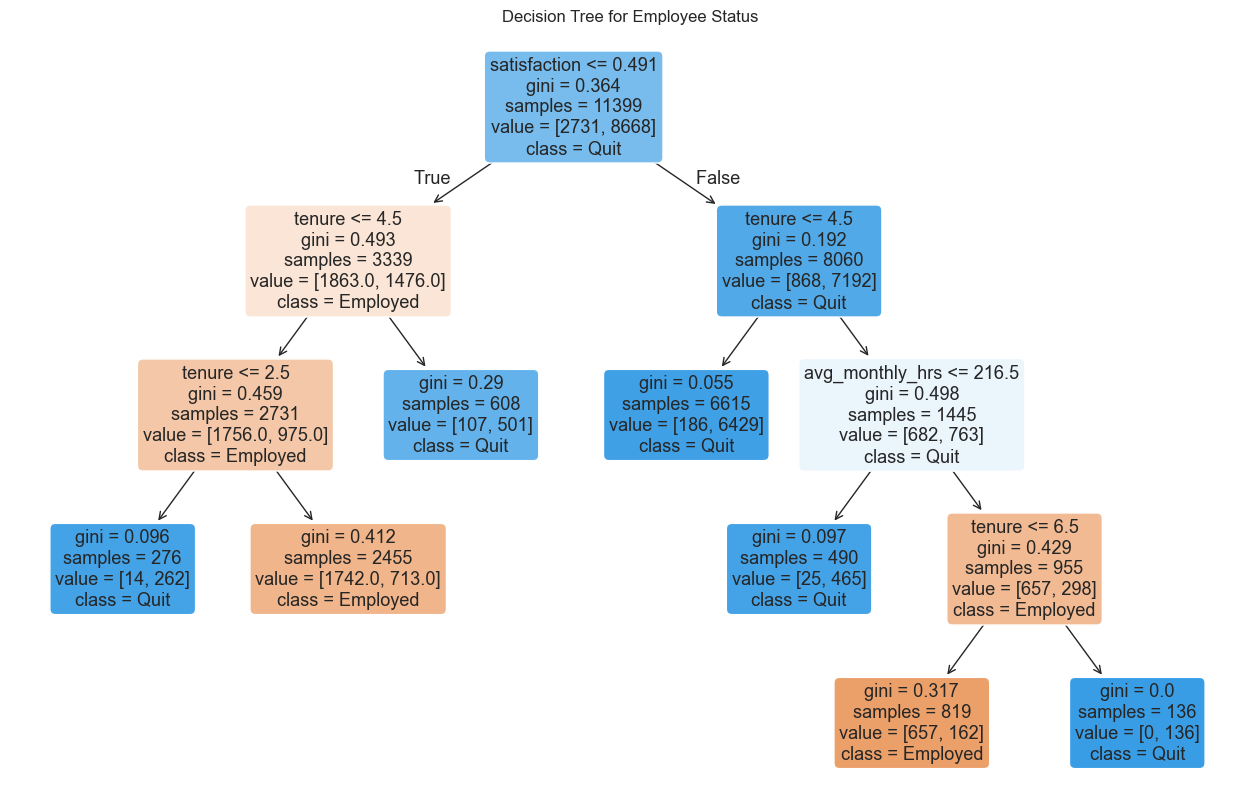

In [47]:
# Interesting features and target
features = ['avg_monthly_hrs', 'filed_complaint', 'satisfaction', 'tenure']
target = 'status'

# Replacing status categories with numerical values
df_custom = df
df_custom['status'] = df_custom['status'].map({"Left": 0, "Employed": 1})

X = df_custom[features]
y = df_custom[target]

# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision tree classifier with a min_impurity_decrease of 0.01
classifier = DecisionTreeClassifier(min_impurity_decrease=0.01, random_state=42)
classifier.fit(X_train, y_train)
y_pred_dt = classifier.predict(X_test)

# Confusion matrix
c_m = confusion_matrix(y_test, y_pred_dt)

# Evaluation the model
accuracy = accuracy_score(y_test, y_pred_dt)
true_positive_rate = c_m[0][0] / (c_m[0][0] + c_m[1][0])
true_negative_rate = c_m[1][1] / (c_m[1][1] + c_m[0][1])
f1_score_0, f1_score_1, recall_0, recall_1 = calculate_f1_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy:.4f}")
print(f"True positive rate: {true_positive_rate:.2f}")
print(f"True negative rate: {true_negative_rate:.2f}")
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

# Visualize the decision tree
plt.figure(figsize=(16, 10))
plot_tree(classifier, feature_names=X.columns, class_names=['Employed', 'Quit'], filled=True, rounded=True)
plt.title("Decision Tree for Employee Status")
plt.show()


## e)

In [48]:
print(
f"""Based on the results from task d), the decision tree does not appear to be overfitted. 
The overall accuracy is {accuracy:.4f}%, and the recall for both classes is equally strong at {recall_0:.2f}%, 
which suggests the model predicts relatively well on unseen data. Despite the imbalance in 
class distribution, the tree achieves a respectable precision of {true_positive_rate:.4f} for the minority class 
(Left/Quit), indicating it is not overly biased toward the majority class (Employed). The use 
of min_impurity_decrease=0.01 likely prevented excessive splits, limiting the tree’s complexity 
and reducing the risk of overfitting. Additionally, the balanced F1-scores for both classes and 
the macro-average F1-score of {round((f1_score_1 + f1_score_0)/2, 4)} further support the claim that the tree is performing well. 
By these reasons I find this decision tree to not be overfitted."""
)

Based on the results from task d), the decision tree does not appear to be overfitted. 
The overall accuracy is 0.9028%, and the recall for both classes is equally strong at 0.90%, 
which suggests the model predicts relatively well on unseen data. Despite the imbalance in 
class distribution, the tree achieves a respectable precision of 0.7376 for the minority class 
(Left/Quit), indicating it is not overly biased toward the majority class (Employed). The use 
of min_impurity_decrease=0.01 likely prevented excessive splits, limiting the tree’s complexity 
and reducing the risk of overfitting. Additionally, the balanced F1-scores for both classes and 
the macro-average F1-score of 0.873 further support the claim that the tree is performing well. 
By these reasons I find this decision tree to not be overfitted.


## f)

In [49]:
# KNN Classifier with K=8
knn_classifier = KNeighborsClassifier(n_neighbors=8)
knn_classifier.fit(X_train, y_train)
y_pred_knn = knn_classifier.predict(X_test)

# Commented out because the task explicitly stated that f1_score has to be calculated manually
# -------------------------------------------------------
# Confusion matrix
# c_m = confusion_matrix(y_test, y_pred_knn)
# 
# # Evaluation the model
# accuracy = accuracy_score(y_test, y_pred_knn)
# true_positive_rate = c_m[0][0] / (c_m[0][0] + c_m[1][0])
# true_negative_rate = c_m[1][1] / (c_m[1][1] + c_m[0][1])
# 
# # Print a detailed classification report
# print(f"Accuracy: {accuracy:.4f}")
# print(f"True positive rate: {true_positive_rate:.2f}")
# print(f"True negative rate: {true_negative_rate:.2f}")
# print("\nKNN Classification Report:")
# print(classification_report(y_test, y_pred_knn))
# -------------------------------------------------------

# Calculating f1_scores from confusion matrix
dt_f1_score_0, dt_f1_score_1, _, _ = calculate_f1_score(y_test, y_pred_dt)
knn_f1_score_0, knn_f1_score_1, _, _ = calculate_f1_score(y_test, y_pred_knn)

# Compare Decision Tree and KNN
print("\nComparison:")
print(f"\tDecision Tree F1-Score: \n\t\t class 0: {dt_f1_score_0} \n\t\t class 1: {dt_f1_score_1} \n\t\t macro avg: {round((dt_f1_score_0 + dt_f1_score_1)/2, 4)}")
print(f"\tKNN F1-Score: \n\t\t class 0: {knn_f1_score_0} \n\t\t class 1: {knn_f1_score_1} \n\t\t macro avg: {round((knn_f1_score_0 + knn_f1_score_1)/2, 4)}")

print(
"""\nBased on the F1 score for both the decision tree and KNN classifiers, 
the KNN model (with K=8) achieves the highest F1 score for class 0 (Left), 
class 1 (Employed), and the macro-average. This indicates that KNN provides 
better overall performance compared to the decision tree, 
making it the better solution of the two."""
)


Comparison:
	Decision Tree F1-Score: 
		 class 0: 0.8114 
		 class 1: 0.9345 
		 macro avg: 0.873
	KNN F1-Score: 
		 class 0: 0.8645 
		 class 1: 0.9542 
		 macro avg: 0.9094

Based on the F1 score for both the decision tree and KNN classifiers, 
the KNN model (with K=8) achieves the highest F1 score for class 0 (Left), 
class 1 (Employed), and the macro-average. This indicates that KNN provides 
better overall performance compared to the decision tree, 
making it the better solution of the two.


## g)

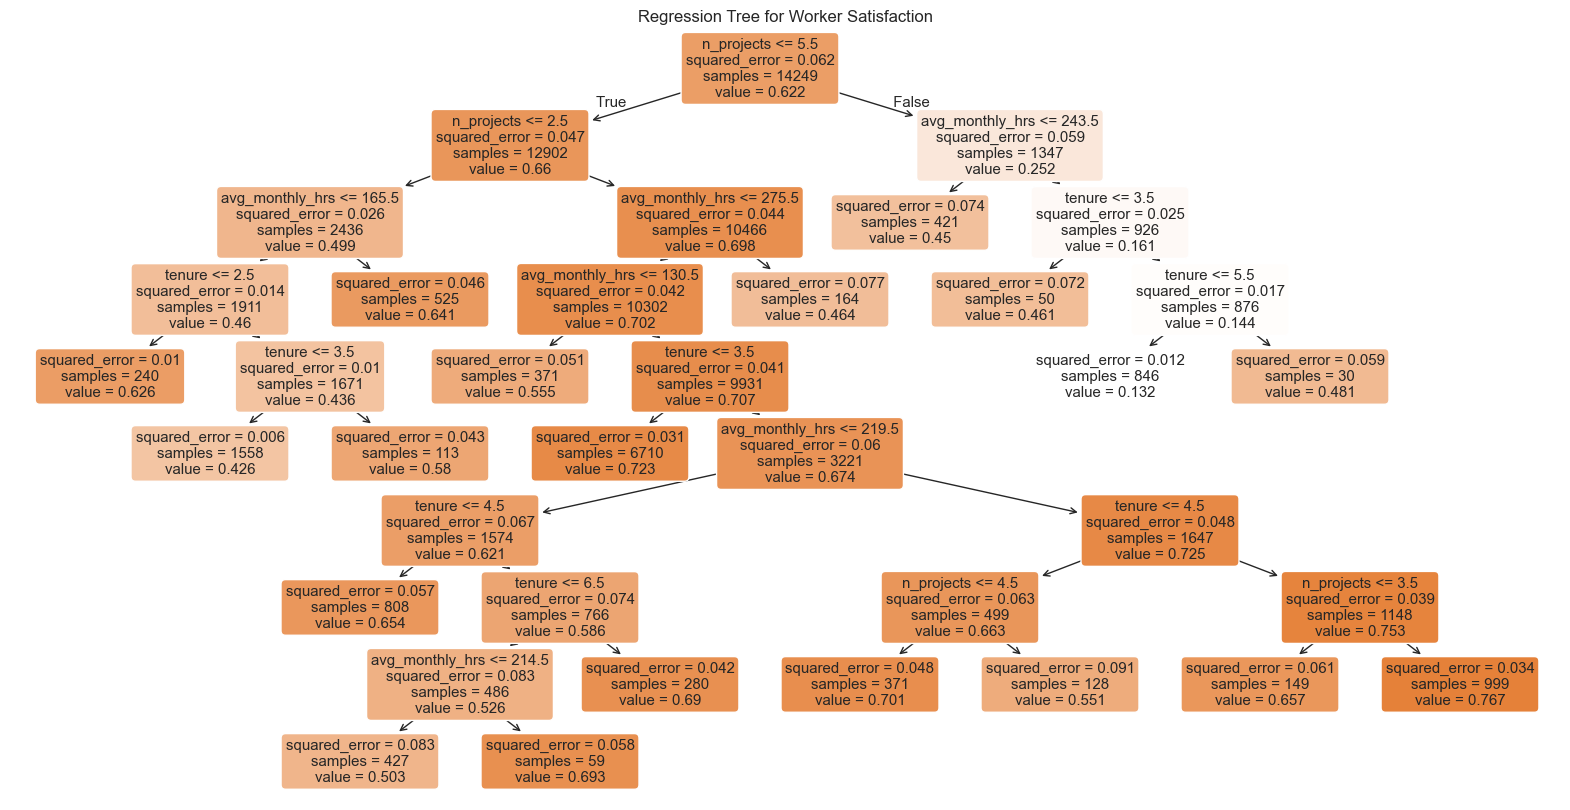

Maximum predicted satisfaction value: 0.7671

Feature ranges for the most satisfied leaf:
n_projects <= 5.50
n_projects > 2.50
avg_monthly_hrs <= 275.50
avg_monthly_hrs > 130.50
tenure > 3.50
avg_monthly_hrs > 219.50
tenure > 4.50
n_projects > 3.50


By implementing this function which traverses backwards from the leaf node up to the root node, 
we find that the parameters of those who are most satisfied (value: 0.7671) in their position to be the following:
3.5 < n_projects <= 5.5, 
219.5 < avg_monthly_hrs <= 275.5, 
and tenure > 4.5



In [50]:
# Assumption:
# Since it is not explicitly stated that this regressor tree is to be used for evaluation, 
# but rather finding the parameters of those who are the most satisfied in their position, 
# I have chosen to ignore splitting into training and testing data

# Features and target
features = ['n_projects', 'tenure', 'avg_monthly_hrs']
target = 'satisfaction'

X = df[features]
y = df[target]

# Train the regression tree
reg_tree = DecisionTreeRegressor(min_impurity_decrease=0.0001, random_state=42)
reg_tree.fit(X, y)


def traverse_tree_to_root(tree_structure, node_index, feature_names):
    """
    Traverses a decision tree from a given node index to the root, 
    collecting feature ranges along the path.
    """
    feature_ranges = []

    while node_index != 0:  # Traverse until the root
        # Get the parent node
        parent = np.where((tree_structure.children_left == node_index) | 
                          (tree_structure.children_right == node_index))[0][0]
        
        # Extract feature index and threshold
        feature_index = tree_structure.feature[parent]
        threshold = tree_structure.threshold[parent]
        direction = "left" if tree_structure.children_left[parent] == node_index else "right"
        
        # Collect the feature range if it's not a leaf node
        if feature_index != -2:
            feature_ranges.append((feature_names[feature_index], threshold, direction))
        
        # Move to the parent node
        node_index = parent

    return list(reversed(feature_ranges))


# Visualize the regression tree
plt.figure(figsize=(20, 10))
plot_tree(reg_tree, feature_names=features, filled=True, rounded=True)
plt.title("Regression Tree for Worker Satisfaction")
plt.show()

# Find the leaf node with the highest satisfaction value
leaf_values = reg_tree.tree_.value.squeeze()
max_leaf_index = np.argmax(leaf_values)
max_satisfaction = leaf_values[max_leaf_index]

print(f"Maximum predicted satisfaction value: {max_satisfaction:.4f}")

# Traverse from the most satisfied leaf to the root
feature_ranges = traverse_tree_to_root(reg_tree.tree_, max_leaf_index, features)

# Display feature ranges
print("\nFeature ranges for the most satisfied leaf:")
for feature, threshold, direction in feature_ranges:
    if direction == "left":
        print(f"{feature} <= {threshold:.2f}")
    else:
        print(f"{feature} > {threshold:.2f}")

print(f"""
\nBy implementing this function which traverses backwards from the leaf node up to the root node, 
we find that the parameters of those who are most satisfied (value: {max_satisfaction:.4f}) in their position to be the following:
3.5 < n_projects <= 5.5, 
219.5 < avg_monthly_hrs <= 275.5, 
and tenure > 4.5
""")